# Нейронная сеть (Keras)
## ВКР: рекомендация соотношения матрица-наполнитель

Блок 3 выпускной квалификационной работы. Строим нейронную сеть, которая
прогнозирует целевой показатель **«Соотношение матрица-наполнитель»**.

**Почему в число входных признаков включены механические свойства
(«Модуль упругости при растяжении, ГПа», «Прочность при растяжении, МПа» и
другие технологические параметры)?**

В отличие от Блока 2, где модели предсказывали механические свойства по
технологическим параметрам состава (и поэтому сами механические свойства не
могли быть признаками — на этапе проектирования они ещё неизвестны), здесь
решается **обратная задача**: инженер задаёт **желаемые свойства
композита** (в том числе механические — модуль упругости и прочность при
растяжении), а также технологические параметры производства, и сеть
**рекомендует**, каким должно быть соотношение матрица-наполнитель, чтобы
получить такой материал. Это классическая постановка "обратного
проектирования" (inverse design): вход — целевые характеристики изделия,
выход — технологический параметр, который нужно установить при изготовлении.
Поэтому здесь утечки данных нет: все 12 оставшихся столбцов датасета
(включая механические свойства) — законный вход, а не результат того же
измерения, что и выход.

In [1]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

FIGURES_DIR = "../figures"
DATA_DIR = "../data/processed"
MODELS_DIR = "../app/models"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


def set_all_seeds(seed=RANDOM_STATE):
    """Фиксирует семена numpy, tensorflow и random для воспроизводимости."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_all_seeds(RANDOM_STATE)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.21.0
Keras: 3.15.1


## 1. Загрузка данных

Используем очищенный датасет `data/processed/data_clean.csv` (после удаления
выбросов методом IQR в Блоке 1). Целевой показатель — **«Соотношение
матрица-наполнитель»**. Входные признаки — **все остальные 12 столбцов**
датасета (технологические параметры и механические свойства, см. пояснение
выше).

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "data_clean.csv"), index_col=0)
print("Размер датасета:", df.shape)

TARGET = "Соотношение матрица-наполнитель"
feature_cols = [c for c in df.columns if c != TARGET]
print(f"Количество входных признаков: {len(feature_cols)}")
for c in feature_cols:
    print(" -", c)

df.head()


Размер датасета: (936, 13)
Количество входных признаков: 12
 - Плотность, кг/м3
 - модуль упругости, ГПа
 - Количество отвердителя, м.%
 - Содержание эпоксидных групп,%_2
 - Температура вспышки, С_2
 - Поверхностная плотность, г/м2
 - Модуль упругости при растяжении, ГПа
 - Прочность при растяжении, МПа
 - Потребление смолы, г/м2
 - Угол нашивки, град
 - Шаг нашивки
 - Плотность нашивки


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0
5,2.767918,2000.0,748.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,60.0
6,2.569620,1910.0,807.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,70.0


## 2. Разбиение на выборки и масштабирование признаков

Разбиение: `train_test_split(test_size=0.3, random_state=42)`.

`MinMaxScaler` для входных признаков `X` обучается (`fit`) **только на
обучающей выборке**, к тестовой выборке применяется только `transform` с уже
рассчитанными параметрами — это исключает утечку данных из тестовой выборки в
обучение. Целевая переменная не масштабируется: её диапазон значений
(~0,55–5,31, см. Блок 1 EDA) уже хорошо подходит для обучения регрессионной
сети с линейным выходом и функцией потерь MSE, а сохранение прогноза в
исходных единицах упрощает использование модели в приложении.

In [3]:
X = df[feature_cols].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_arr = y_train.to_numpy(dtype="float32")
y_test_arr = y_test.to_numpy(dtype="float32")

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print(f"y_train: {y_train_arr.shape}, y_test: {y_test_arr.shape}")


X_train: (655, 12), X_test: (281, 12)
y_train: (655,), y_test: (281,)


## 3. Архитектура нейронной сети

Используем `Sequential` из Keras: полносвязные слои `Dense` с активацией
`ReLU`, слои `Dropout` для регуляризации и выходной слой из одной линейной
нейроны (регрессия). Компилируем с оптимизатором `Adam`, функцией потерь
`MSE` и метрикой `MAE`. Обучение — до 300 эпох, `batch_size=32`,
`validation_split=0.2`, с `EarlyStopping(patience=20,
restore_best_weights=True)`, чтобы не переобучаться и автоматически вернуть
веса лучшей по валидационной ошибке эпохи.

In [4]:
def build_model(hidden_layers, input_dim, dropout_rate=0.2, seed=RANDOM_STATE):
    set_all_seeds(seed)
    model = keras.Sequential(name="nn_ratio")
    model.add(keras.Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation="linear"))
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


def train_model(hidden_layers, input_dim=X_train_scaled.shape[1]):
    model = build_model(hidden_layers, input_dim)
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    )
    history = model.fit(
        X_train_scaled, y_train_arr,
        validation_split=0.2,
        epochs=300,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    return model, history


## 4. Сравнение архитектур

Обучаем три архитектуры скрытых слоёв: **64-32**, **128-64-32** и **32-16**
(везде с `Dropout(0.2)` после каждого скрытого слоя), и сравниваем их по
метрикам на тестовой выборке.

In [5]:
ARCHITECTURES = {
    "64-32": [64, 32],
    "128-64-32": [128, 64, 32],
    "32-16": [32, 16],
}

trained = {}
comparison_rows = []

for arch_name, hidden_layers in ARCHITECTURES.items():
    model, history = train_model(hidden_layers)
    epochs_trained = len(history.history["loss"])
    min_val_loss = float(np.min(history.history["val_loss"]))

    y_train_pred = model.predict(X_train_scaled, verbose=0).ravel()
    y_test_pred = model.predict(X_test_scaled, verbose=0).ravel()

    train_metrics = regression_metrics(y_train_arr, y_train_pred)
    test_metrics = regression_metrics(y_test_arr, y_test_pred)

    trained[arch_name] = {"model": model, "history": history}

    comparison_rows.append({
        "Архитектура": arch_name,
        "Эпох обучено": epochs_trained,
        "min_val_loss": min_val_loss,
        "MAE_train": train_metrics["MAE"],
        "RMSE_train": train_metrics["RMSE"],
        "R2_train": train_metrics["R2"],
        "MAE_test": test_metrics["MAE"],
        "RMSE_test": test_metrics["RMSE"],
        "R2_test": test_metrics["R2"],
    })
    print(f"{arch_name:12s} эпох={epochs_trained:3d}  "
          f"min_val_loss={min_val_loss:.4f}  R2_test={test_metrics['R2']:.4f}  MAE_test={test_metrics['MAE']:.4f}")

comparison_table = pd.DataFrame(comparison_rows).sort_values(
    "min_val_loss", ascending=True
).reset_index(drop=True)
comparison_table.to_csv(os.path.join(FIGURES_DIR, "nn_architectures.csv"), index=False, encoding="utf-8-sig")
comparison_table


64-32        эпох= 58  min_val_loss=0.7888  R2_test=-0.0123  MAE_test=0.7086


128-64-32    эпох= 44  min_val_loss=0.7897  R2_test=-0.0176  MAE_test=0.7116


32-16        эпох=127  min_val_loss=0.7756  R2_test=-0.0137  MAE_test=0.7012


,Архитектура,Эпох обучено,min_val_loss,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test
0,32-16,127,0.775604,0.715176,0.891039,0.023465,0.701181,0.878719,-0.013729
1,64-32,58,0.788847,0.725280,0.898845,0.006281,0.708565,0.878110,-0.012325
2,128-64-32,44,0.789744,0.712530,0.886596,0.033180,0.711550,0.880389,-0.017587


### Выбор итоговой архитектуры

Лучшей считается архитектура с минимальным `min_val_loss` (минимальным MSE
на валидационной части обучающей выборки, `validation_split=0.2`), а не с
максимальным R² на тесте — тест используется только для итоговой,
информационной оценки уже выбранной архитектуры.

In [6]:
best_arch_name = comparison_table.iloc[0]["Архитектура"]
print(f"Выбранная архитектура (по минимальному min_val_loss): {best_arch_name} -> {ARCHITECTURES[best_arch_name]}")
print(comparison_table.to_string(index=False))


Выбранная архитектура (по минимальному min_val_loss): 32-16 -> [32, 16]
Архитектура  Эпох обучено  min_val_loss  MAE_train  RMSE_train  R2_train  MAE_test  RMSE_test   R2_test
      32-16           127      0.775604   0.715176    0.891039  0.023465  0.701181   0.878719 -0.013729
      64-32            58      0.788847   0.725280    0.898845  0.006281  0.708565   0.878110 -0.012325
  128-64-32            44      0.789744   0.712530    0.886596  0.033180  0.711550   0.880389 -0.017587


## 5. Итоговая модель: анализ и метрики

Ниже подробно разбираем выбранную архитектуру: структура сети, кривые
обучения, качество прогноза на тестовой выборке и сравнение с наивным
базовым прогнозом (среднее значение по обучающей выборке — аналог
`DummyRegressor(strategy="mean")` из Блока 2).

In [7]:
best_model = trained[best_arch_name]["model"]
best_history = trained[best_arch_name]["history"]

best_model.summary()


Model: "nn_ratio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,885 (11.27 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,924 (7.52 KB)

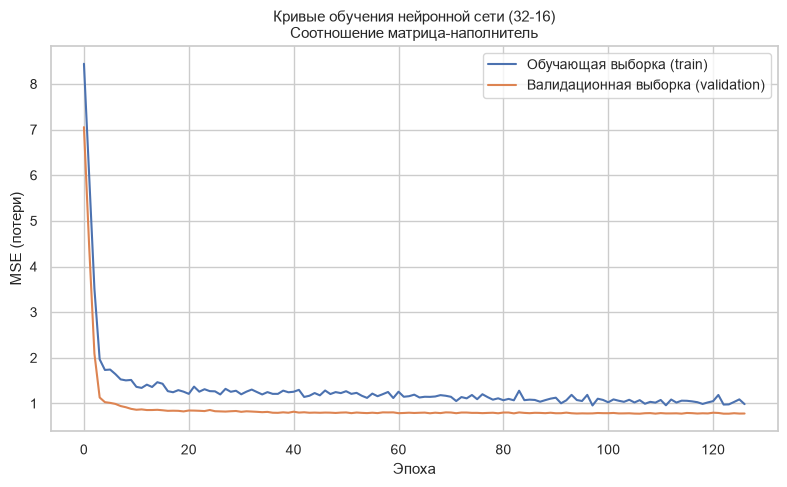

In [8]:
history_df = pd.DataFrame(best_history.history)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["loss"], label="Обучающая выборка (train)")
ax.plot(history_df["val_loss"], label="Валидационная выборка (validation)")
ax.set_xlabel("Эпоха")
ax.set_ylabel("MSE (потери)")
ax.set_title(f"Кривые обучения нейронной сети ({best_arch_name})\nСоотношение матрица-наполнитель")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "nn_loss_curves.png"), dpi=300, bbox_inches="tight")
plt.show()


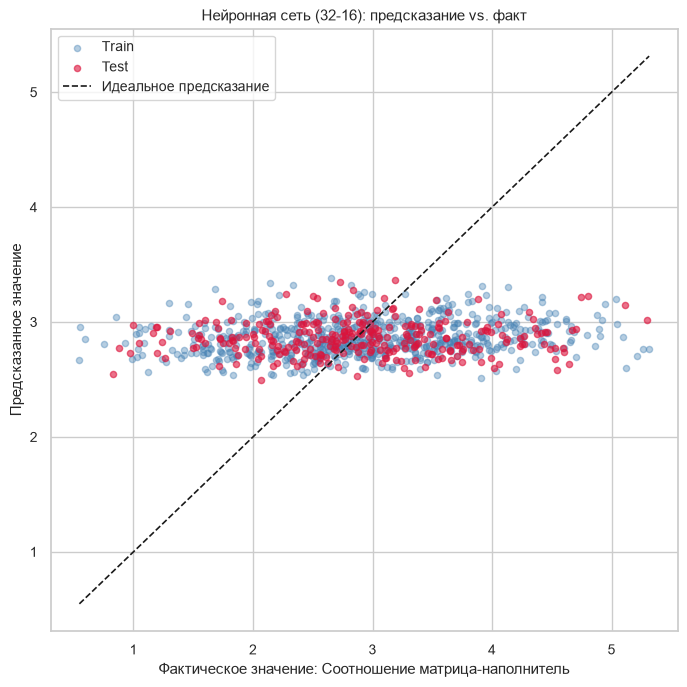

In [9]:
y_train_pred = best_model.predict(X_train_scaled, verbose=0).ravel()
y_test_pred = best_model.predict(X_test_scaled, verbose=0).ravel()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_train_arr, y_train_pred, alpha=0.4, s=20, color="steelblue", label="Train")
ax.scatter(y_test_arr, y_test_pred, alpha=0.6, s=20, color="crimson", label="Test")
lims = [
    min(y_train_arr.min(), y_test_arr.min(), y_train_pred.min(), y_test_pred.min()),
    max(y_train_arr.max(), y_test_arr.max(), y_train_pred.max(), y_test_pred.max()),
]
ax.plot(lims, lims, "k--", linewidth=1.2, label="Идеальное предсказание")
ax.set_xlabel("Фактическое значение: Соотношение матрица-наполнитель")
ax.set_ylabel("Предсказанное значение")
ax.set_title(f"Нейронная сеть ({best_arch_name}): предсказание vs. факт")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "nn_prediction_vs_actual.png"), dpi=300, bbox_inches="tight")
plt.show()


In [10]:
baseline_value = y_train_arr.mean()
baseline_train_pred = np.full_like(y_train_arr, baseline_value)
baseline_test_pred = np.full_like(y_test_arr, baseline_value)

metrics_rows = [
    {
        "Модель": f"Нейронная сеть ({best_arch_name})",
        **{f"{k}_train": v for k, v in regression_metrics(y_train_arr, y_train_pred).items()},
        **{f"{k}_test": v for k, v in regression_metrics(y_test_arr, y_test_pred).items()},
    },
    {
        "Модель": "Baseline (среднее по train)",
        **{f"{k}_train": v for k, v in regression_metrics(y_train_arr, baseline_train_pred).items()},
        **{f"{k}_test": v for k, v in regression_metrics(y_test_arr, baseline_test_pred).items()},
    },
]
metrics_nn = pd.DataFrame(metrics_rows)
metrics_nn.to_csv(os.path.join(FIGURES_DIR, "metrics_nn.csv"), index=False, encoding="utf-8-sig")
metrics_nn


,Модель,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test
0,Нейронная сеть (32-16),0.715176,0.793951,0.891039,0.023465,0.701181,0.772147,0.878719,-0.013729
1,Baseline (среднее по train),0.725842,0.813029,0.901681,0.000000,0.694175,0.762885,0.873433,-0.001569


**Интерпретация (по фактическим результатам выше):**

- Выбранная по `min_val_loss` архитектура — **32-16** (min_val_loss =
  0.7756, 127 эпох до срабатывания `EarlyStopping`). У архитектур 64-32 и
  128-64-32 min_val_loss выше (0.7888 и 0.7897 соответственно), хотя по
  R2_test 64-32 выглядела бы чуть лучше (-0.0123 против -0.0137 у 32-16) —
  это ровно тот случай, когда отбор по валидации, а не по тесту, меняет
  выбор: тестовая метрика здесь не согласуется с более надёжной
  валидационной оценкой.
- **Честно: нейронная сеть не превосходит наивный baseline** (среднее по
  train). На тестовой выборке R2_test сети = -0.0137 хуже, чем у baseline
  (-0.0016); MAE_test сети = 0.7012 против 0.6942 у baseline; RMSE_test =
  0.8787 против 0.8734 у baseline — по всем трём метрикам baseline не хуже
  или немного лучше сети. На обучающей выборке сеть объясняет лишь R2_train
  = 0.0235 (2,3%) дисперсии целевого показателя.
- Вывод согласуется с Блоком 2: сеть не находит содержательной зависимости
  между 12 входными признаками и «Соотношением матрица-наполнитель» —
  результат приводится без приукрашивания, дополнительной ценности по
  сравнению с прогнозом константой (средним) сеть не даёт.

## 6. Сохранение модели и скейлера

Сохраняем обученную модель в формате Keras (`app/models/nn_ratio.keras`) и
`MinMaxScaler` признаков (`app/models/nn_scaler.joblib`), чтобы их можно было
использовать в приложении без повторного обучения.

In [11]:
model_path = os.path.join(MODELS_DIR, "nn_ratio.keras")
scaler_path = os.path.join(MODELS_DIR, "nn_scaler.joblib")

best_model.save(model_path)
joblib.dump(scaler, scaler_path)

print("Модель сохранена:", model_path)
print("Скейлер сохранён:", scaler_path)


Модель сохранена: ../app/models\nn_ratio.keras
Скейлер сохранён: ../app/models\nn_scaler.joblib


## Выводы

- Целевой показатель «Соотношение матрица-наполнитель» прогнозируется
  нейронной сетью на основе всех 12 оставшихся столбцов датасета, включая
  желаемые механические свойства (постановка обратного проектирования).
- Признаки масштабированы `MinMaxScaler`, обученным только на train — без
  утечки данных.
- Сопоставлены три архитектуры скрытых слоёв (64-32, 128-64-32, 32-16) с
  `Dropout(0.2)` и `EarlyStopping`; выбрана архитектура с минимальным
  `min_val_loss` (таблица сравнения сохранена в `figures/nn_architectures.csv`,
  раздел 4), тест использован только для информационной оценки уже выбранной
  архитектуры.
- Метрики MAE, MSE, RMSE и R² на train/test для лучшей сети и для наивного
  baseline (среднее по train) сохранены в `figures/metrics_nn.csv`; честно:
  сеть не превосходит baseline (см. интерпретацию в разделе 5).
- Кривые обучения и график предсказание-vs-факт сохранены в `figures/`.
- Модель и скейлер сохранены в `app/models/nn_ratio.keras` и
  `app/models/nn_scaler.joblib` для использования в приложении.